In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

from scipy.stats import uniform, randint

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.metrics import Precision, Recall, F1Score

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [4]:
#df = pd.read_csv('/content/drive/MyDrive/26S/ML/ML PROJECT/CLASSIFICATION_TASK/diabetes_prediction_dataset.csv')
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [5]:
df.shape

(100000, 9)

In [6]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [8]:
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(96146, 9)

In [11]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [12]:
df.nunique()

gender                    3
age                     102
hypertension              2
heart_disease             2
smoking_history           6
bmi                    4247
HbA1c_level              18
blood_glucose_level      18
diabetes                  2
dtype: int64

In [13]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# **EDA**

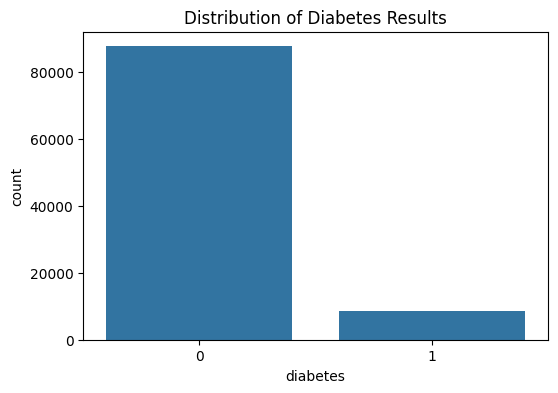

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', data=df)
plt.title('Distribution of Diabetes Results')
plt.show()

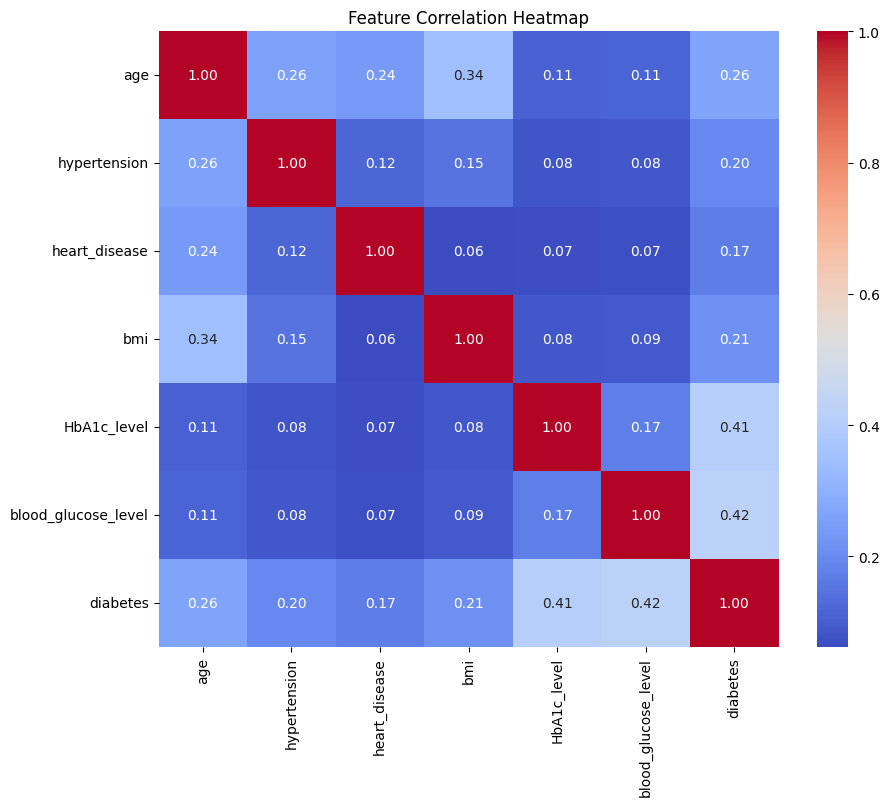

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

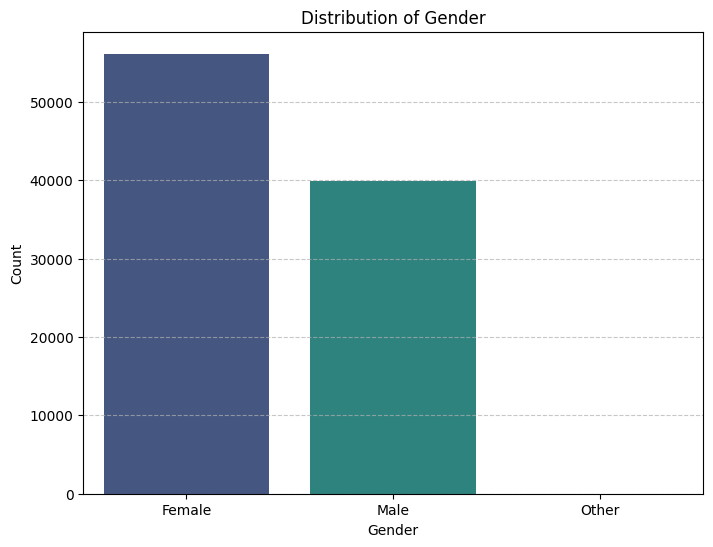

In [16]:
plt.figure(figsize=(8, 6))
sns.countplot(x='gender', data=df, palette='viridis', hue='gender', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

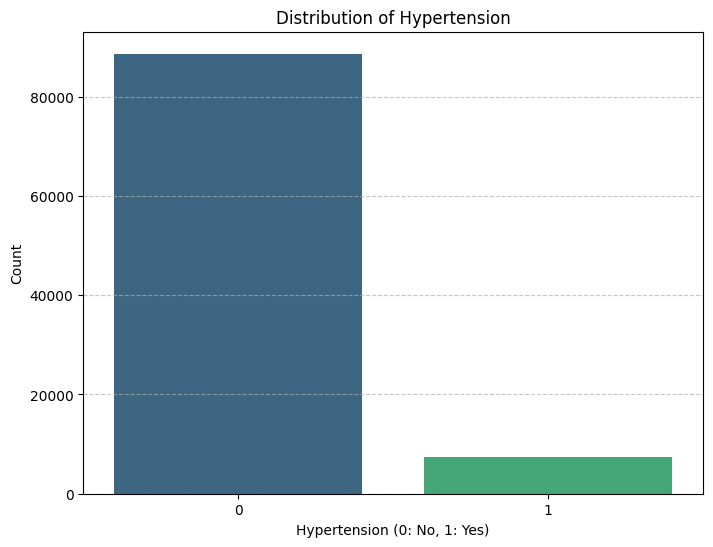

In [17]:
plt.figure(figsize=(8, 6))
sns.countplot(x='hypertension', hue='hypertension', data=df, palette='viridis', legend=False)
plt.title('Distribution of Hypertension')
plt.xlabel('Hypertension (0: No, 1: Yes)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

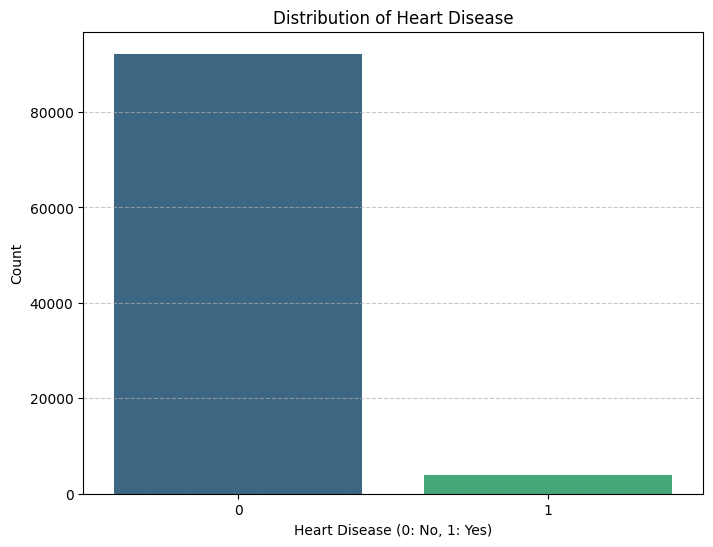

In [18]:
plt.figure(figsize=(8, 6))
sns.countplot(x='heart_disease', hue='heart_disease', data=df, palette='viridis', legend=False)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease (0: No, 1: Yes)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

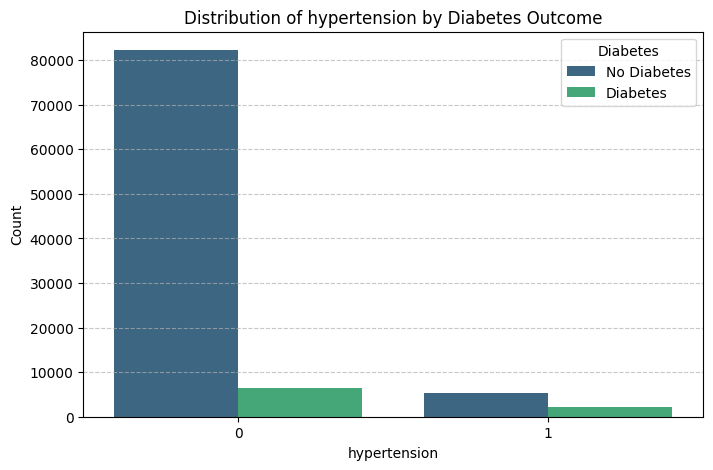

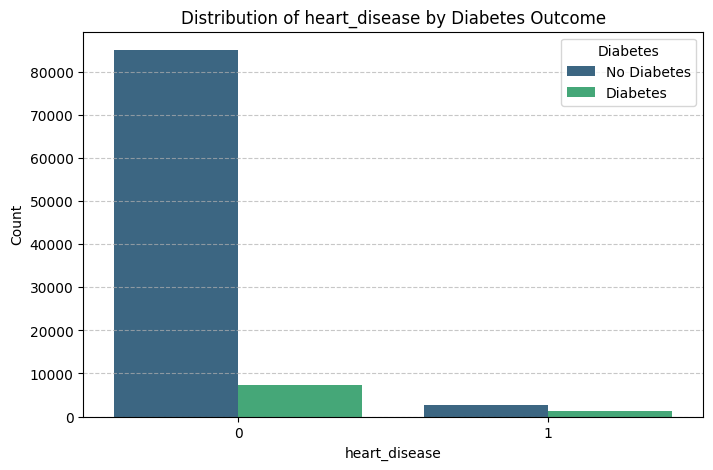

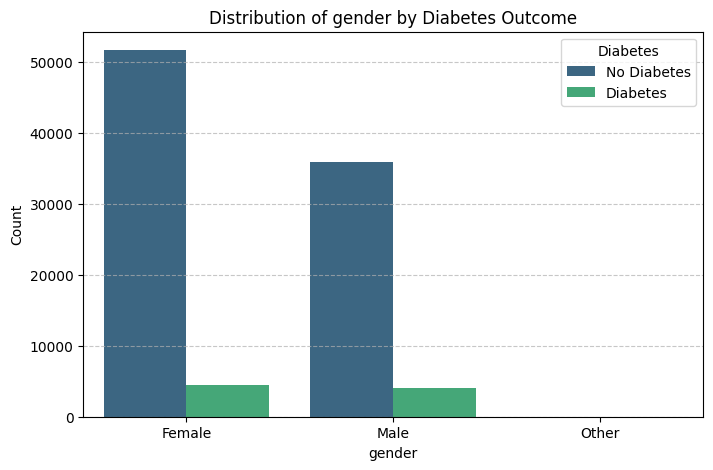

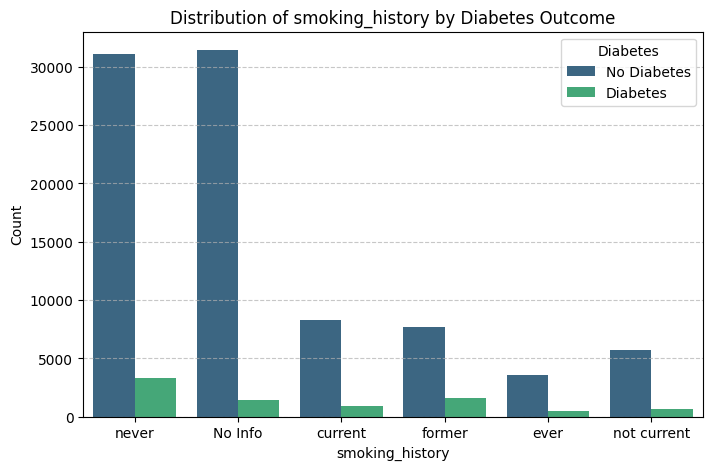

In [19]:
categorical_cols = [
    'hypertension', 'heart_disease', 'gender', 'smoking_history'
]

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue='diabetes', data=df, palette='viridis')
    plt.title(f'Distribution of {col} by Diabetes Outcome')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Diabetes', labels=['No Diabetes', 'Diabetes'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

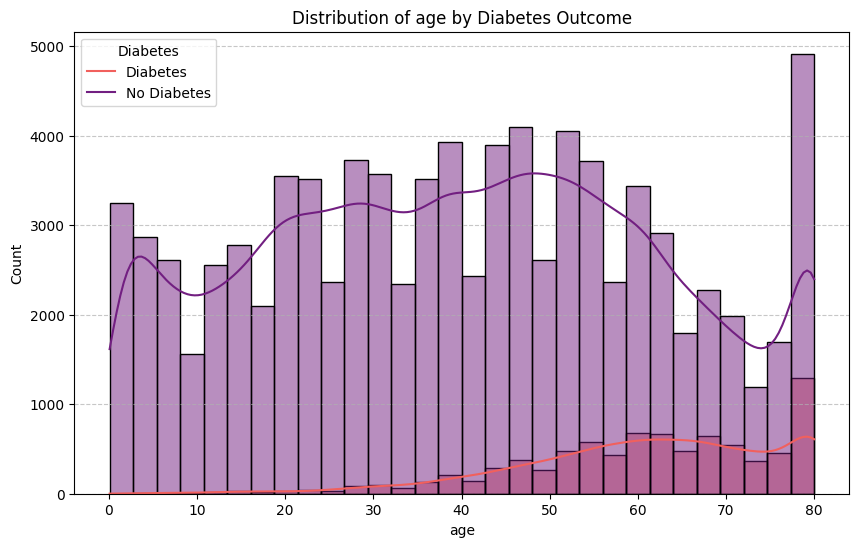

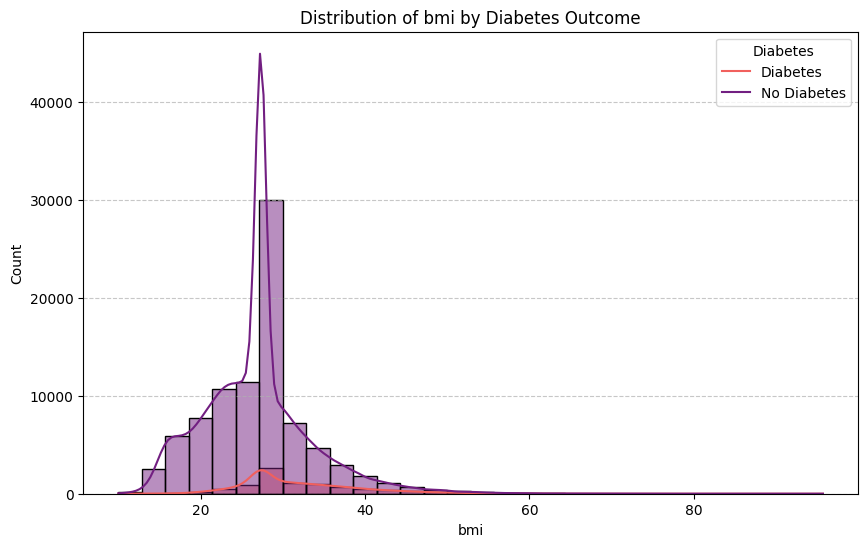

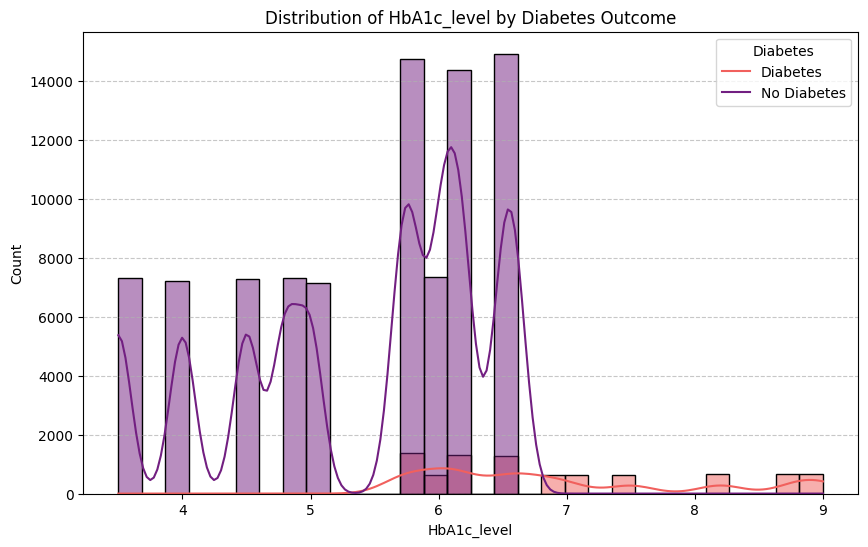

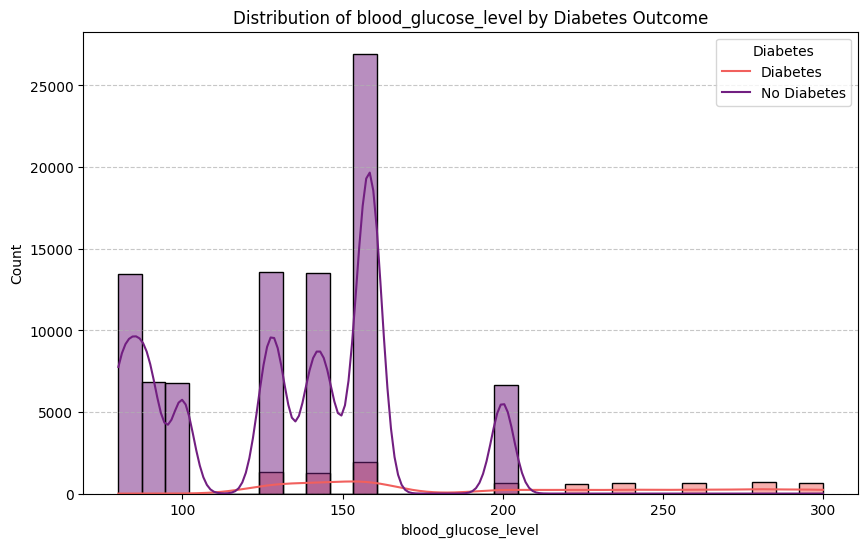

In [20]:
numerical_cols = [
    'age', 'bmi', 'HbA1c_level', 'blood_glucose_level'
]

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, hue='diabetes', kde=True, palette='magma', bins=30)
    plt.title(f'Distribution of {col} by Diabetes Outcome')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Diabetes', labels=['Diabetes', 'No Diabetes'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [21]:
df_scatter = df.copy()
df_scatter['diabetes_status'] = df_scatter['diabetes'].map({0: 'No Diabetes', 1: 'Diabetes'})

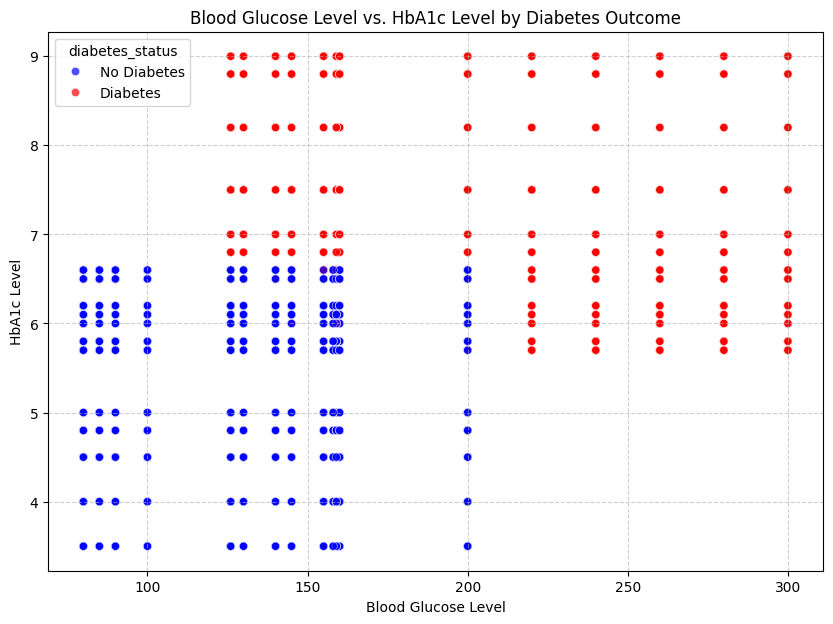

In [22]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='blood_glucose_level', y='HbA1c_level', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, alpha=0.7)
plt.title('Blood Glucose Level vs. HbA1c Level by Diabetes Outcome')
plt.xlabel('Blood Glucose Level')
plt.ylabel('HbA1c Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

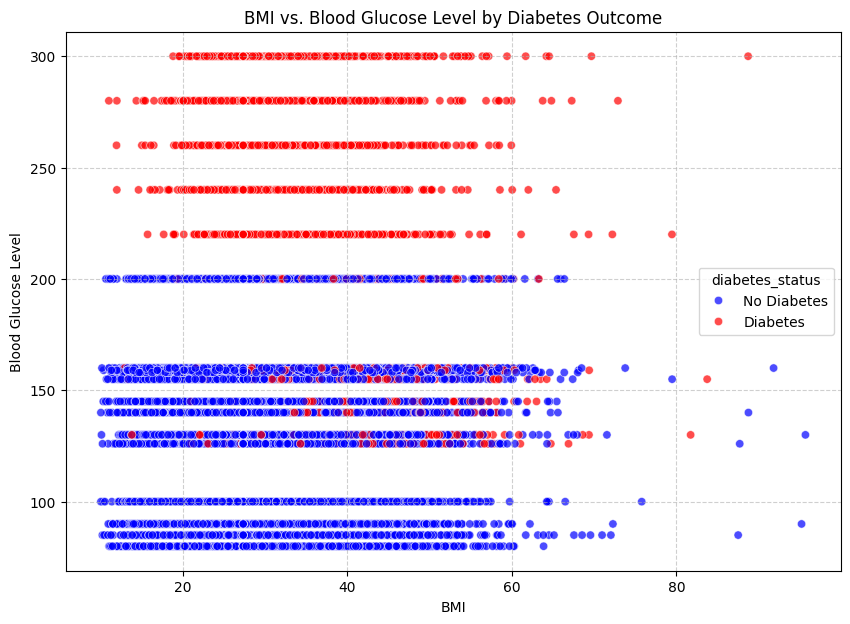

In [23]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='bmi', y='blood_glucose_level', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, alpha=0.7)
plt.title('BMI vs. Blood Glucose Level by Diabetes Outcome')
plt.xlabel('BMI')
plt.ylabel('Blood Glucose Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

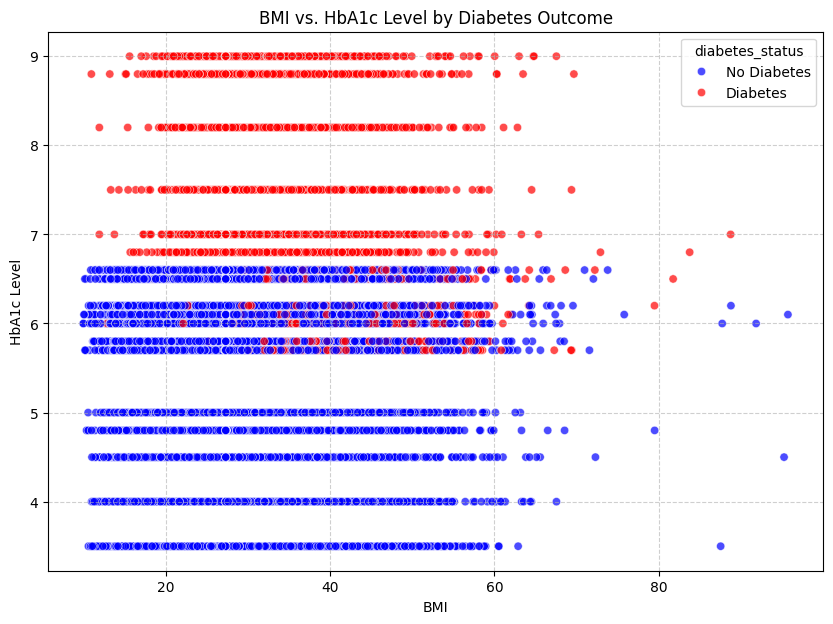

In [24]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='bmi', y='HbA1c_level', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, alpha=0.7)
plt.title('BMI vs. HbA1c Level by Diabetes Outcome')
plt.xlabel('BMI')
plt.ylabel('HbA1c Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

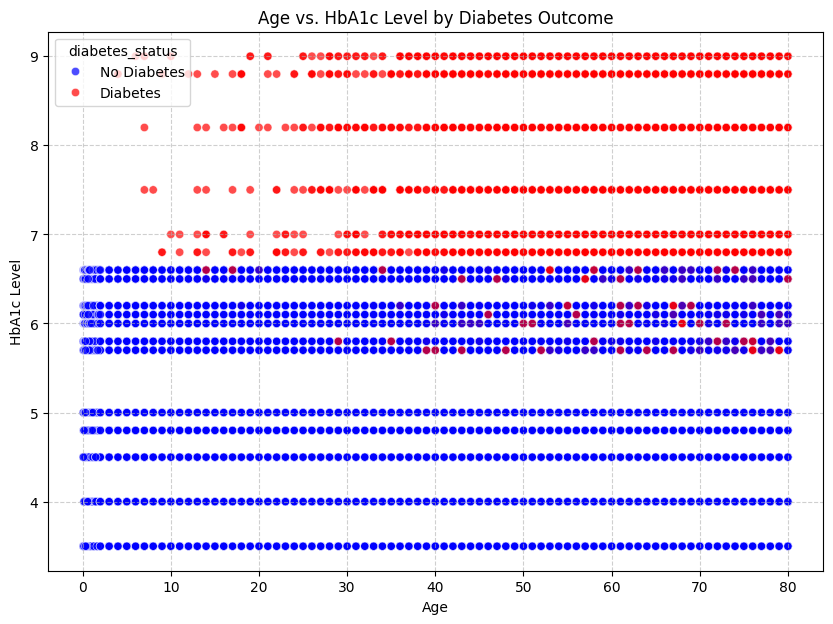

In [25]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='age', y='HbA1c_level', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, alpha=0.7)
plt.title('Age vs. HbA1c Level by Diabetes Outcome')
plt.xlabel('Age')
plt.ylabel('HbA1c Level')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

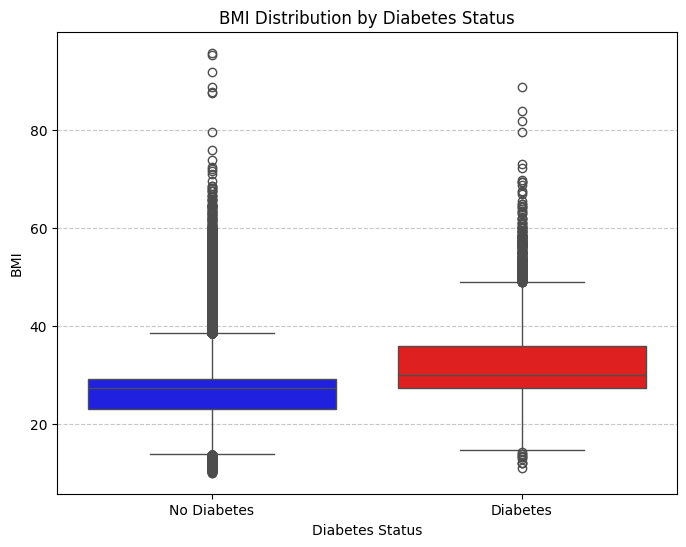

In [26]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='diabetes_status', y='bmi', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, legend=False)
plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('BMI')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Feature Engineering**

In [27]:
df = df[(df['bmi'] >= 15) & (df['bmi'] <= 35)]
df_scatter = df.copy()
df_scatter['diabetes_status'] = df_scatter['diabetes'].map({0: 'No Diabetes', 1: 'Diabetes'})

In [28]:
df.shape

(83905, 9)

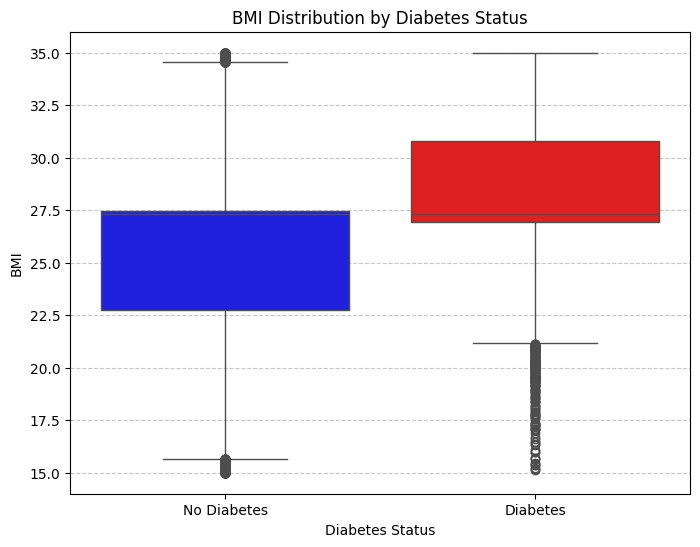

In [29]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='diabetes_status', y='bmi', hue='diabetes_status', data=df_scatter, palette={'No Diabetes': 'blue', 'Diabetes': 'red'}, legend=False)
plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('BMI')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [30]:
print(df['smoking_history'].unique())

['never' 'No Info' 'current' 'ever' 'former' 'not current']


In [31]:
df = pd.get_dummies(df, columns=['gender'])

smoking_mapping = {
    'never': 1,
    'former': 2,
    'current': 3,
    'not current': 2,
    'ever': 1,
    'No Info': 0
}
df['smoking_history'] = df['smoking_history'].map(smoking_mapping)

In [32]:
df_non_engineered = df.copy()
df['glucose_high'] = (df['blood_glucose_level'] > 140).astype(int)
df['hba1c_high'] = (df['HbA1c_level'] >= 6.5).astype(int)
df['glucose_bmi'] = df['blood_glucose_level'] * df['bmi']
df['hba1c_age'] = df['HbA1c_level'] * df['age']

def bmi_category(bmi):
    if bmi < 18.5:
        return 0
    elif bmi < 25:
        return 1
    elif bmi < 30:
        return 2
    else:
        return 3

df['bmi_cat'] = df['bmi'].apply(bmi_category)

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 45, 60, 100],
    labels=[0, 1, 2, 3]
).astype(int)

df['risk_score'] = (
    (df['HbA1c_level'] >= 6.5).astype(int) +
    (df['blood_glucose_level'] > 140).astype(int) +
    (df['bmi'] > 30).astype(int)
)

In [33]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [34]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

In [35]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [36]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

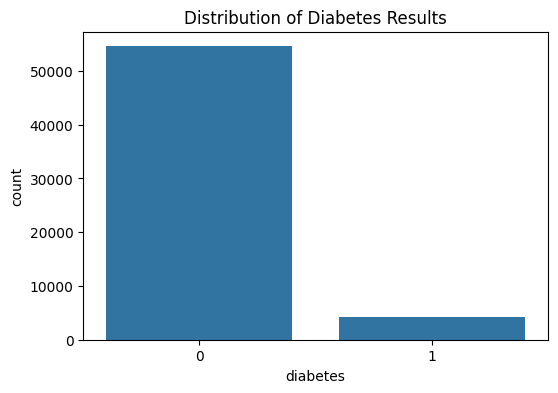

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', data=pd.DataFrame(y_train, columns=['diabetes']))
plt.title('Distribution of Diabetes Results')
plt.show()

In [38]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X.select_dtypes(
    include=['object', 'category', 'string']
).columns

# **PCA**

Original number of features: 17
Number of components after PCA: 10
Explained variance ratio: [0.26545711 0.15286875 0.11840102 0.10115937 0.08356184 0.05883306
 0.05417807 0.05277828 0.05075606 0.03004072]


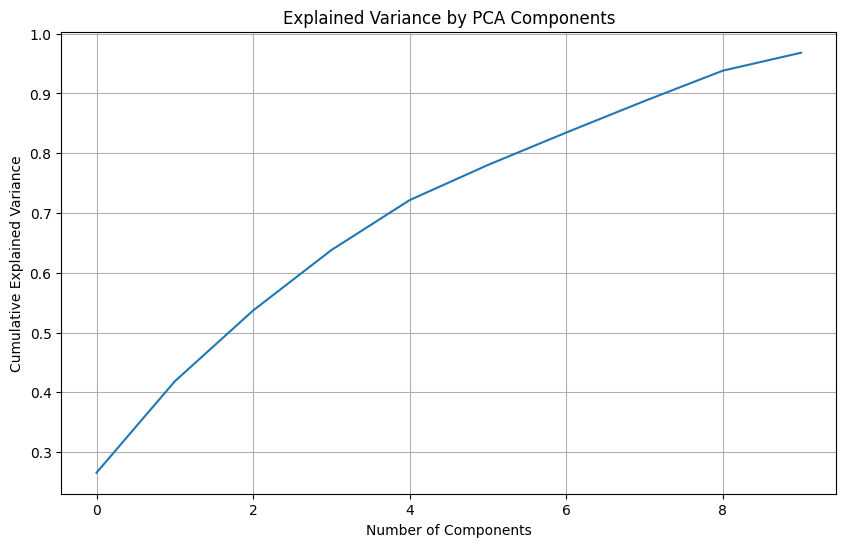

In [39]:
scaler_pca = StandardScaler()
pca = PCA(n_components=0.95)

X_train_scaled = scaler_pca.fit_transform(X_train)
X_val_scaled = scaler_pca.transform(X_val)
X_test_scaled = scaler_pca.transform(X_test)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of components after PCA: {X_train_pca.shape[1]}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

In [40]:
PCA_numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

PCA_categorical_features = X.select_dtypes(include=['object', 'category', 'string']).columns

# **Model Implementation**

# **MLP**



In [41]:
param_distributions = {
    'hidden_layer_sizes': [(64, 32), (32, 16,), (64, 32, 16)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': uniform(0.0001, 0.01),
    'learning_rate_init': [0.001, 0.005, 0.01],
    'max_iter': [100, 200, 300],
    'batch_size': [32, 64, 128],
}

rs = RandomizedSearchCV(
    estimator=MLPClassifier(random_state=42, early_stopping=True),
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring=('f1', 'f1_macro'),
    refit='f1',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rs.fit(X_train_pca, y_train)

print("Best parameters found: ", rs.best_params_)
print("Best cross-validation score: {:.2f}%".format(rs.best_score_ * 100))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters found:  {'activation': 'tanh', 'alpha': np.float64(0.004597541333697657), 'batch_size': 64, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.005, 'max_iter': 300, 'solver': 'adam'}
Best cross-validation score: 78.69%


In [42]:
best_mlp = rs.best_estimator_

y_pred_val = best_mlp.predict(X_val_pca)

mlp_accuracy_val = accuracy_score(y_val, y_pred_val)
mlp_report_val = classification_report(y_val, y_pred_val)

print(f"Validation Accuracy with MLP: {mlp_accuracy_val*100:.2f}%")
print("Validation Classification Report with MLP:\n", mlp_report_val)

y_pred= best_mlp.predict(X_test_pca)

mlp_accuracy = accuracy_score(y_test, y_pred)
mlp_report= classification_report(y_test, y_pred)

print(f"Test Accuracy with MLP: {mlp_accuracy*100:.2f}%")
print("Test Classification Report with MLP:\n", mlp_report)

Validation Accuracy with MLP: 97.13%
Validation Classification Report with MLP:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     11630
           1       0.97      0.64      0.77       956

    accuracy                           0.97     12586
   macro avg       0.97      0.82      0.88     12586
weighted avg       0.97      0.97      0.97     12586

Test Accuracy with MLP: 97.24%
Test Classification Report with MLP:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     11644
           1       0.96      0.66      0.78       942

    accuracy                           0.97     12586
   macro avg       0.96      0.83      0.88     12586
weighted avg       0.97      0.97      0.97     12586



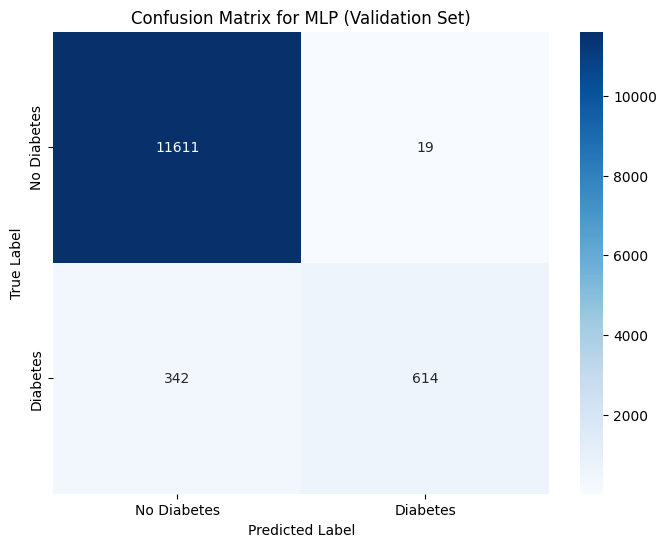

In [43]:
mlp_conf_matrix_val = confusion_matrix(y_val, y_pred_val)

plt.figure(figsize=(8, 6))
sns.heatmap(mlp_conf_matrix_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix for MLP (Validation Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

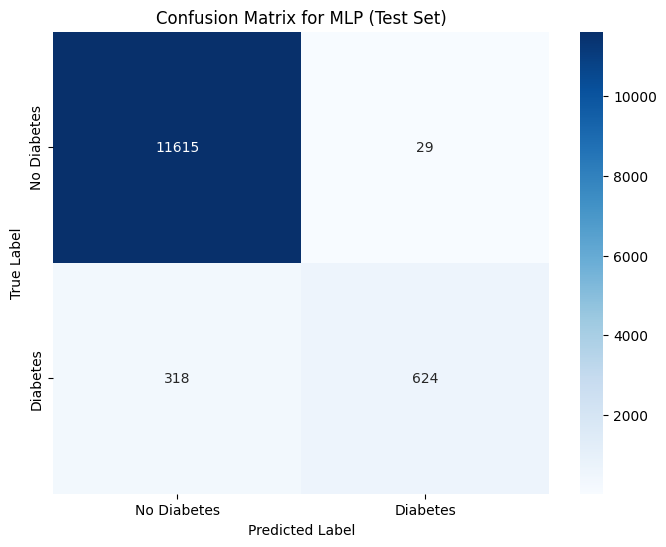

In [44]:
mlp_conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(mlp_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix for MLP (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [45]:
y_pred_proba = best_mlp.predict_proba(X_test_pca)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

f_scores = []
for i in range(len(thresholds)):
    y_pred_threshold = (y_pred_proba >= thresholds[i]).astype(int)
    f_scores.append(f1_score(y_test, y_pred_threshold, pos_label=1))

f_scores = np.array(f_scores)

optimal_f1_threshold_index = np.argmax(f_scores)
optimal_f1_threshold = thresholds[optimal_f1_threshold_index]
print(f"Optimal Threshold for F1-score: {optimal_f1_threshold:.4f}")
print(f"Max F1-score: {f_scores[optimal_f1_threshold_index]:.4f}")
print(f"Precision at optimal F1-threshold: {precision[optimal_f1_threshold_index]:.4f}")
print(f"Recall at optimal F1-threshold: {recall[optimal_f1_threshold_index]:.4f}")

optimal_precision_threshold_index = np.argmax(precision[:-1])
optimal_precision_threshold = thresholds[optimal_precision_threshold_index]
print(f"\nOptimal Threshold for Max Precision: {optimal_precision_threshold:.4f}")
print(f"Max Precision: {precision[optimal_precision_threshold_index]:.4f}")
print(f"Recall at optimal Precision-threshold: {recall[optimal_precision_threshold_index]:.4f}")
print(f"F1-score at optimal Precision-threshold: {f_scores[optimal_precision_threshold_index]:.4f}")

optimal_recall_threshold_index = np.argmax(recall[:-1])
optimal_recall_threshold = thresholds[optimal_recall_threshold_index]
print(f"\nOptimal Threshold for Max Recall: {optimal_recall_threshold:.4f}")
print(f"Max Recall: {recall[optimal_recall_threshold_index]:.4f}")
print(f"Precision at optimal Recall-threshold: {precision[optimal_recall_threshold_index]:.4f}")
print(f"F1-score at optimal Recall-threshold: {f_scores[optimal_recall_threshold_index]:.4f}")


Optimal Threshold for F1-score: 0.6428
Max F1-score: 0.7885
Precision at optimal F1-threshold: 0.9857
Recall at optimal F1-threshold: 0.6571

Optimal Threshold for Max Precision: 0.9160
Max Precision: 1.0000
Recall at optimal Precision-threshold: 0.6285
F1-score at optimal Precision-threshold: 0.7718

Optimal Threshold for Max Recall: 0.0000
Max Recall: 1.0000
Precision at optimal Recall-threshold: 0.0748
F1-score at optimal Recall-threshold: 0.1393


In [46]:
mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[F1Score(average='macro', name='f1_score'),Precision(name='precision'),
        Recall(name='recall')])

history = mlp_model.fit(X_train_pca, y_train, epochs=50, batch_size=64, validation_data=(X_val_pca, y_val))

val_results = mlp_model.evaluate(X_val_pca, y_val)
print(f"Validation F1 Score: {val_results[1]:.4f}")
print(f"Validation Precision: {val_results[2]:.4f}")
print(f"Validation Recall: {val_results[3]:.4f}")

test_results = mlp_model.evaluate(X_test_pca, y_test)
print(f"Test F1 Score: {test_results[1]:.4f}")
print(f"Test Precision: {test_results[2]:.4f}")
print(f"Test Recall: {test_results[3]:.4f}")

Epoch 1/50


c:\Users\ranao\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - f1_score: 0.1337 - loss: 0.1533 - precision: 0.7288 - recall: 0.4643 - val_f1_score: 0.1413 - val_loss: 0.1072 - val_precision: 0.8905 - val_recall: 0.5952
Epoch 2/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - f1_score: 0.1347 - loss: 0.1128 - precision: 0.8578 - recall: 0.5663 - val_f1_score: 0.1417 - val_loss: 0.1011 - val_precision: 0.9751 - val_recall: 0.5732
Epoch 3/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - f1_score: 0.1359 - loss: 0.1036 - precision: 0.9089 - recall: 0.5840 - val_f1_score: 0.1425 - val_loss: 0.0969 - val_precision: 0.9624 - val_recall: 0.5889
Epoch 4/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - f1_score: 0.1370 - loss: 0.1006 - precision: 0.9326 - recall: 0.5790 - val_f1_score: 0.1462 - val_loss: 0.0953 - val_precision: 0.9660 - val_recall: 0.5941
Epoch 5/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - f1_score: 0.1401 - loss: 0.0980 - precision: 0.9411 - recall: 0.5799 - val_f1_score: 0.1467 - val_loss: 0.0944 - val_

In [47]:
predictions_val = mlp_model.predict(X_val_pca)

y_pred_val = (predictions_val > 0.5).astype(int)
y_true_val = y_val

report_val = classification_report(y_true_val, y_pred_val)
print(report_val)

predictions = mlp_model.predict(X_test_pca)

y_pred = (predictions > 0.5).astype(int)
y_true = y_test

report = classification_report(y_true, y_pred)
print(report)

394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     11630
           1       0.99      0.63      0.77       956

    accuracy                           0.97     12586
   macro avg       0.98      0.82      0.88     12586
weighted avg       0.97      0.97      0.97     12586

394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     11644
           1       0.99      0.65      0.79       942

    accuracy                           0.97     12586
   macro avg       0.98      0.83      0.89     12586
weighted avg       0.97      0.97      0.97     12586



In [48]:
print("Confusion Matrix for Validation Set:")
cm_val = confusion_matrix(y_true=y_true_val, y_pred=y_pred_val)
print(cm_val)

print("\nConfusion Matrix for Test Set:")
cm = confusion_matrix(y_true=y_true, y_pred=y_pred)
print(cm)

Confusion Matrix for Validation Set:
[[11626     4]
 [  352   604]]

Confusion Matrix for Test Set:
[[11639     5]
 [  325   617]]


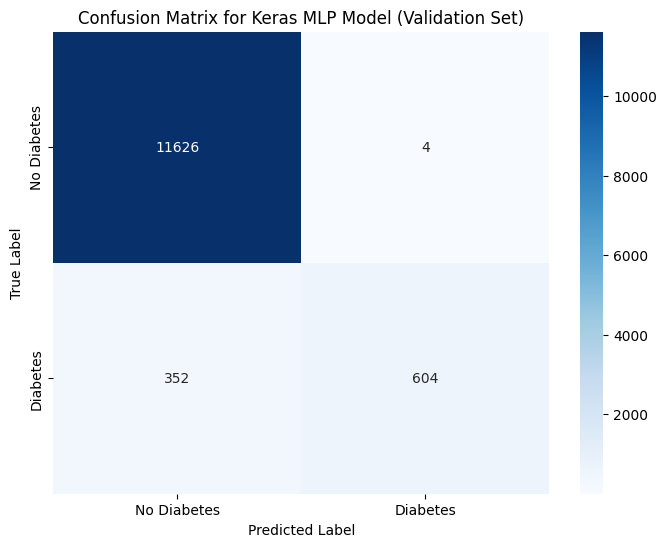

In [49]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix for Keras MLP Model (Validation Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

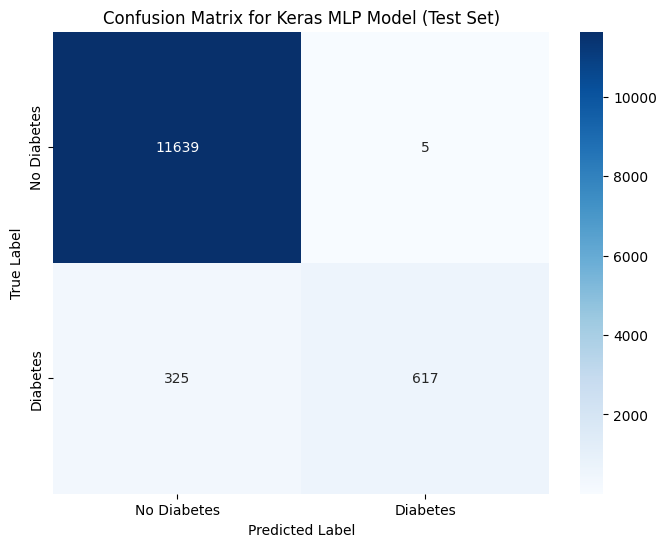

In [50]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix for Keras MLP Model (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

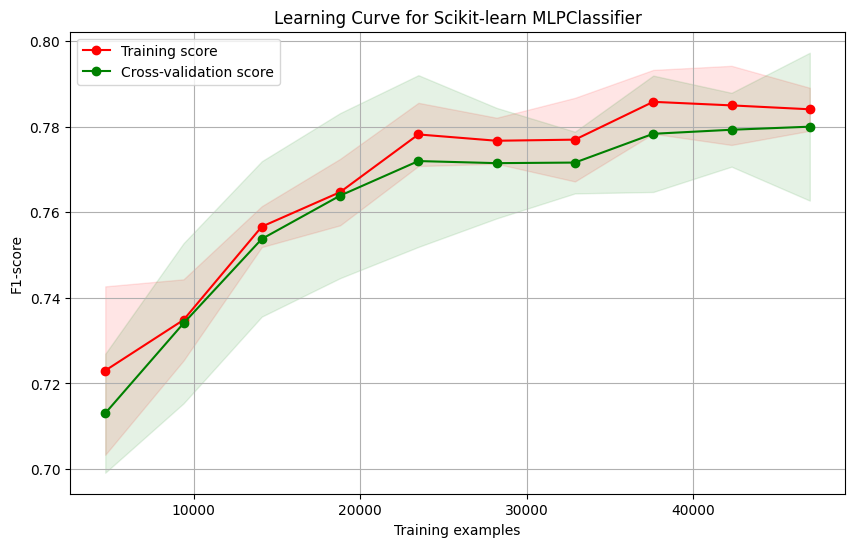

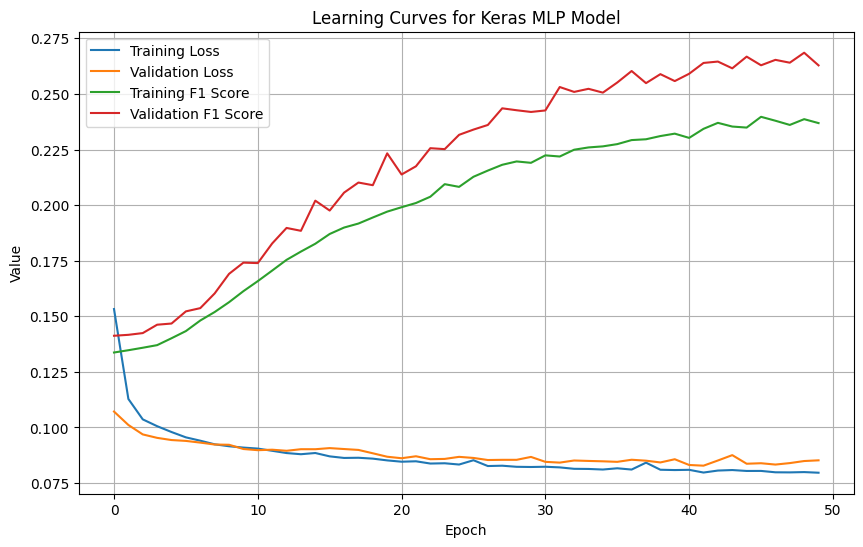

In [51]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_mlp,
    X=X_train_pca,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1'
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1,
                 color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Cross-validation score")

plt.title("Learning Curve for Scikit-learn MLPClassifier")
plt.xlabel("Training examples")
plt.ylabel("F1-score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# Learning Curve for Keras MLP Model
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['f1_score'], label='Training F1 Score')
plt.plot(history.history['val_f1_score'], label='Validation F1 Score')
plt.title('Learning Curves for Keras MLP Model')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 20}
Best Threshold (VAL): 0.7499999999999997
Best F1 (VAL): 0.787571337983513

Accuracy Score:
0.9757667249324646

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     11644
           1       1.00      0.68      0.81       942

    accuracy                           0.98     12586
   macro avg       0.99      0.84      0.90     12586
weighted avg       0.98      0.98      0.97     12586



<Figure size 600x500 with 0 Axes>

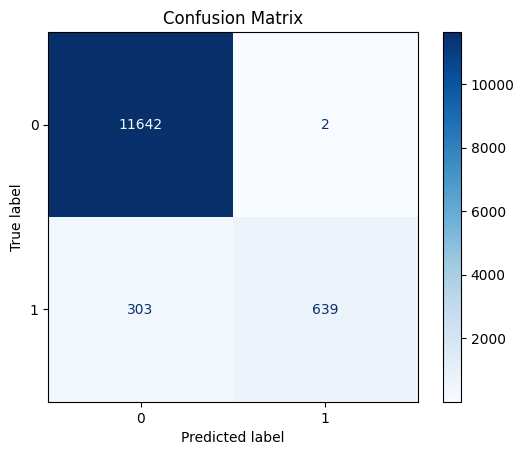

                Feature  Importance
10            hba1c_age    0.209415
5           HbA1c_level    0.205992
6   blood_glucose_level    0.152765
9           glucose_bmi    0.138313
0                   age    0.082442
4                   bmi    0.046085
13           risk_score    0.045277
12            age_group    0.040291
8            hba1c_high    0.028996
3       smoking_history    0.017605
7          glucose_high    0.010857
1          hypertension    0.009640
11              bmi_cat    0.006965
2         heart_disease    0.005358


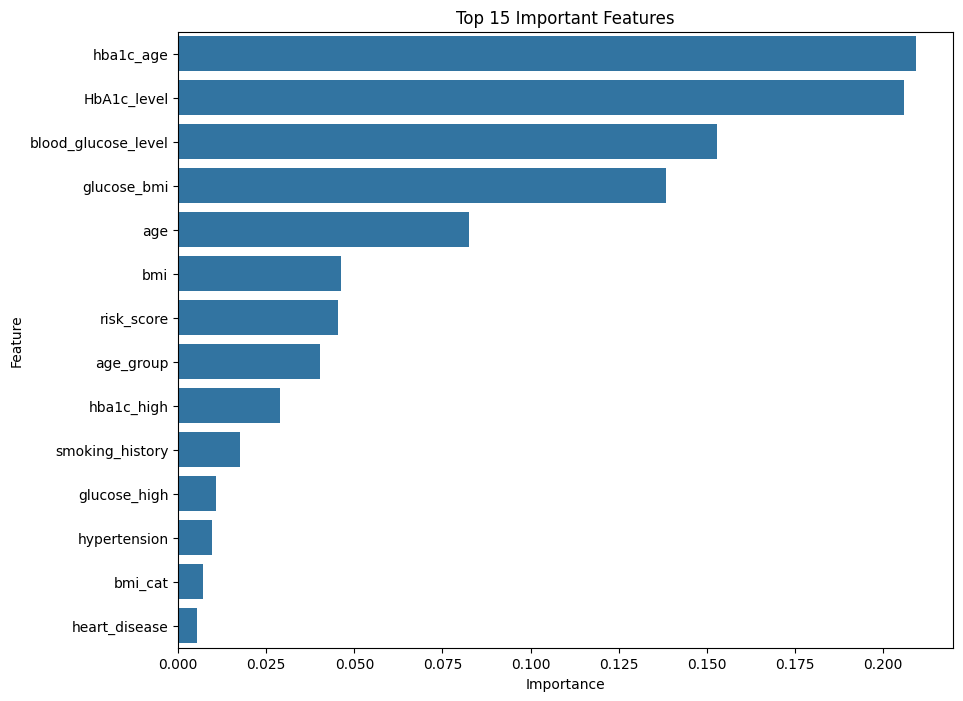

In [53]:
## Random Forest Model 


rf_model = RandomForestClassifier(
    n_estimators=800,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced_subsample',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# =========================
# CATEGORICAL PIPELINE
# =========================

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

# ============================================
# HYPERPARAMETER GRID
# ============================================

param_grid = {
    'classifier__n_estimators': [200, 500, 800],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# ============================================
# RANDOMIZED SEARCH
# ============================================

random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# ============================================
# TRAIN SEARCH
# ============================================

random_search.fit(X_train, y_train)

# ============================================
# BEST PARAMETERS
# ============================================

print("Best Parameters:")
print(random_search.best_params_)

# =========================
# PREDICT PROBABILITIES
# =========================

best_rf_model = random_search.best_estimator_

y_val_probs = best_rf_model.predict_proba(X_val)[:, 1]

# =========================
# CUSTOM THRESHOLD
# =========================

best_threshold = 0
best_f1 = 0

# Try thresholds from 0.1 to 0.9
thresholds = np.arange(0.1, 0.9, 0.01)

for t in thresholds:
    y_val_pred = (y_val_probs >= t).astype(int)
    score = f1_score(y_val, y_val_pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best Threshold (VAL):", best_threshold)
print("Best F1 (VAL):", best_f1)

y_test_probs = best_rf_model.predict_proba(X_test)[:, 1]

y_test_pred = (y_test_probs >= best_threshold).astype(int)


# =========================
# 15. MODEL EVALUATION
# =========================

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


# =========================
# 16. CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


# =========================
# FEATURE IMPORTANCE
# =========================

# Get fitted pipeline
best_pipeline = random_search.best_estimator_

# Get trained RF model
trained_rf = best_pipeline.named_steps['classifier']

# Get fitted preprocessor
fitted_preprocessor = best_pipeline.named_steps['preprocessor']

# Get encoded categorical names if available
encoded_cat_features = np.array([])
if len(categorical_features) > 0:
    try:
        fitted_encoder = fitted_preprocessor.named_transformers_[
            'cat'
        ].named_steps['encoder']
        encoded_cat_features = fitted_encoder.get_feature_names_out(
            categorical_features
        )
    except Exception as exc:
        print('Warning: Unable to extract encoded categorical feature names:', exc)
        encoded_cat_features = np.array([])

# Combine all feature names
if encoded_cat_features.size > 0:
    all_feature_names = np.concatenate([
        numeric_features,
        encoded_cat_features
    ])
else:
    all_feature_names = np.array(numeric_features, dtype=object)

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': trained_rf.feature_importances_
})

# Sort
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

# =========================
# PLOT
# =========================

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Important Features')
plt.show()
